<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/sign_lang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import requests
import zipfile
from pathlib import Path

# setup path to data folder
data_path = Path("data/")
image_path =data_path / "sign-language"

#if the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory exists")
else:
  print(f"{image_path} doenot exist,creating one ...")
  image_path.mkdir(parents=True,exist_ok=True)

  #download pizza, steak and sushi data
  with open(data_path/"sign-lang.zip","wb") as f:
    requests=requests.get("https://github.com/Manav010203/hand-sign/raw/refs/heads/cloudmain/archive%20(4).zip")
    print("Downloading data..")
    f.write(requests.content)

  #unzip file
  with zipfile.ZipFile(data_path/"sign-lang.zip","r") as zip_ref:
    print("unzippind data...")
    zip_ref.extractall(image_path)

data/sign-language directory exists


In [41]:
import os
def walk_through_dir(dir_path):
  """walks thorgh dir_path returning its contents..."""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [42]:
walk_through_dir(image_path)

there are 1 directories and 0 images in 'data/sign-language'
there are 2 directories and 0 images in 'data/sign-language/ASL_Gestures_36_Classes'
there are 36 directories and 0 images in 'data/sign-language/ASL_Gestures_36_Classes/test'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/5'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/c'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/3'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/d'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/g'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/b'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/4'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/a'
there are 0 directo

In [43]:
train_data_path = image_path / "ASL_Gestures_36_Classes" / "train"
test_data_path = image_path / "ASL_Gestures_36_Classes" / "test"

In [44]:
train_data_path,test_data_path

(PosixPath('data/sign-language/ASL_Gestures_36_Classes/train'),
 PosixPath('data/sign-language/ASL_Gestures_36_Classes/test'))

In [45]:
image_path_list = list[image_path.glob("*/*/*/*/*.jpeg")]

data/sign-language/ASL_Gestures_36_Classes/test/m/hand2_m_left_seg_2_cropped.jpeg
m
random image path:data/sign-language/ASL_Gestures_36_Classes/test/m/hand2_m_left_seg_2_cropped.jpeg
Image class:m
Image height:400
Image width:400


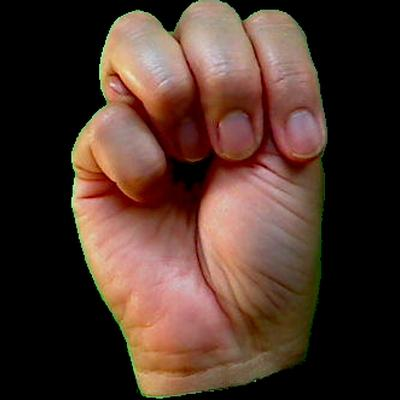

In [46]:
import random
from PIL import Image

# random.seed(42)

#1. Get all image paths
image_path_list=list(image_path.glob("*/*/*/*.jpeg"))
# image_path_list

#2 pick a random image path

random_imag_path = random.choice(image_path_list)
print(random_imag_path)

#3 Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_imag_path.parent.stem
print(image_class)

#4 open image
img =Image.open(random_imag_path)

#5 print metadata
print(f"random image path:{random_imag_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width:{img.width}")
img

Text(0.5, 1.0, 'image clas :m | image shape :(400, 400, 3) ')

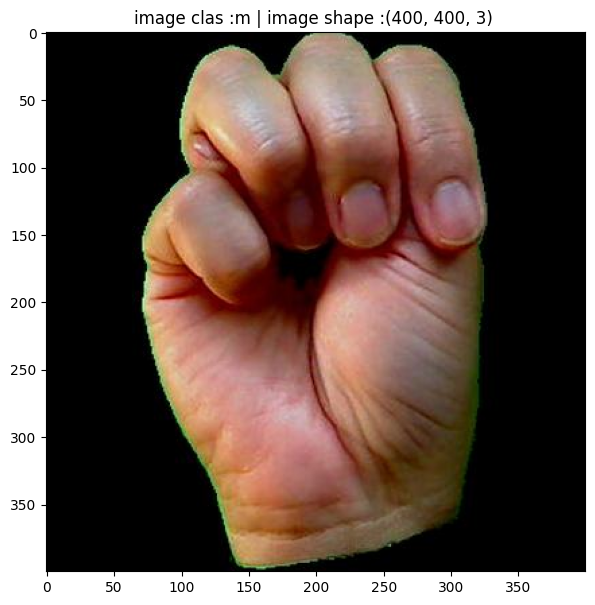

In [47]:
import matplotlib.pyplot as plt
import numpy as np
# trun image into array
imag_as_arr = np.asarray(img)
# imag_as_arr.shape


# plt.imshow(img)
plt.figure(figsize=(10,7))
plt.imshow(imag_as_arr)
plt.title(f"image clas :{image_class} | image shape :{imag_as_arr.shape} ")

In [48]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [49]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_data_path,
                                  transform=transform)
test_data = datasets.ImageFolder(root=test_data_path,
                                 transform=transform)
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 2011
    Root location: data/sign-language/ASL_Gestures_36_Classes/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 504
    Root location: data/sign-language/ASL_Gestures_36_Classes/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [50]:
class_name = train_data.classes
class_name

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [53]:
len(train_data),len(test_data)

(2011, 504)

In [54]:
train_data.samples[0]

('data/sign-language/ASL_Gestures_36_Classes/train/0/hand1_0_bot_seg_1_cropped.jpeg',
 0)

In [55]:
img,label = train_data[77][0],train_data[77][1]
print(f"image shape:{img.shape}")
print(f"label:{label}")
print(f"dtyep:{img.dtype}")

image shape:torch.Size([3, 224, 224])
label:1
dtyep:torch.float32


In [56]:
size_transform = transforms.Resize((224,224))

In [58]:
img_permute =img.permute(1,2,0)
img_permute.shape
# class_name[label]

torch.Size([224, 224, 3])

In [61]:
from torch.utils.data import DataLoader
train_data_dataloader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=2)
test_data_dataloader = DataLoader(test_data,batch_size=32,shuffle=True,num_workers=2)
train_data_dataloader,test_data_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7f1c57e88610>,
 <torch.utils.data.dataloader.DataLoader at 0x7f1c57e8b5d0>)

In [62]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [75]:
class Sign_lang(nn.Module):
  def __init__(self,
               input_shape:int,
               out_shape:int,
               hidden_unit:int):
    super().__init__()
    self.Conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                                  out_channels=hidden_unit,
                                  kernel_size=3,
                                  stride =1,
                                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                                  out_channels=hidden_unit,
                                  kernel_size=3,
                                  stride =1,
                                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                                  stride=2)
        )
    self.Conv_layer_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.MaxPool2d(kernel_size=2,
                    stride=2)
    )
    self.clasifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_unit*56*56,
                  out_features=out_shape)
    )
  def forward(self,x):
    x=self.Conv_layer_1(x)
    x=self.Conv_layer_2(x)
    x=self.clasifier(x)
    return x


In [76]:
model_0 = Sign_lang(input_shape=3,
                    out_shape=len(class_name),
                    hidden_unit=10)

In [77]:
image_batch,label = next(iter(train_data_dataloader))
image_batch.shape,label.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [78]:
model_0(image_batch)

tensor([[-0.0186,  0.0519,  0.0777,  ..., -0.1150,  0.0427,  0.0116],
        [-0.0183,  0.0557,  0.0711,  ..., -0.1185,  0.0398,  0.0067],
        [-0.0223,  0.0585,  0.0721,  ..., -0.1151,  0.0379,  0.0065],
        ...,
        [-0.0167,  0.0573,  0.0749,  ..., -0.1173,  0.0402,  0.0095],
        [-0.0156,  0.0540,  0.0766,  ..., -0.1226,  0.0425, -0.0024],
        [-0.0140,  0.0514,  0.0791,  ..., -0.1159,  0.0376,  0.0063]],
       grad_fn=<AddmmBackward0>)